# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('ispu_dki1_raw.csv') # Sesuaikan path jika di Colab

# Mengubah format tanggal dan memotong data dari 2021 ke atas
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')
df_awal = df.copy() # Simpan data utuh untuk perbandingan
df = df[df['tanggal'].dt.year >= 2021].copy()

print(f"Jumlah data keseluruhan: {len(df_awal)} baris")
print(f"Jumlah data (2021-2025): {len(df)} baris")

Jumlah data keseluruhan: 5173 baris
Jumlah data (2021-2025): 1155 baris


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset (2021+):
<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 4018 to 5172
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   tanggal   1155 non-null   datetime64[ns]
 1   stasiun   1155 non-null   object        
 2   pm25      1146 non-null   float64       
 3   pm10      1151 non-null   float64       
 4   so2       1142 non-null   float64       
 5   co        1137 non-null   float64       
 6   o3        1149 non-null   float64       
 7   no2       1149 non-null   float64       
 8   max       1151 non-null   float64       
 9   critical  1151 non-null   object        
 10  categori  1155 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 108.3+ KB

Distribusi Kategori Kualitas Udara:
categori
SEDANG            913
BAIK              192
TIDAK SEHAT        46
TIDAK ADA DATA      4
Name: count, dtype: int64


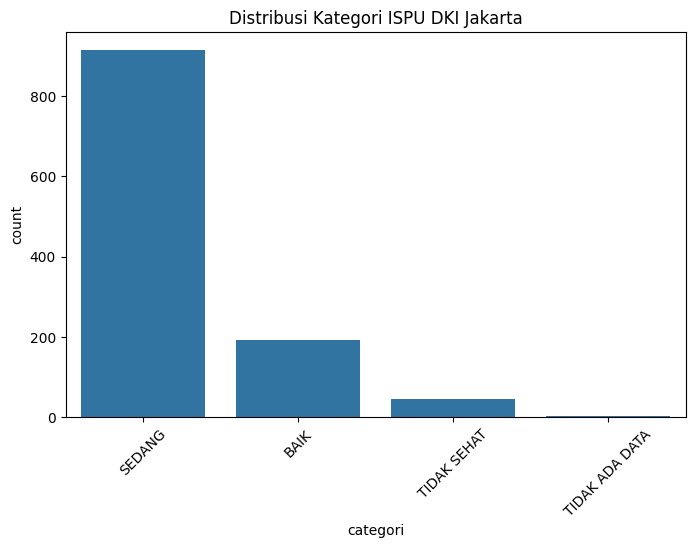

In [3]:
print("Informasi Dataset (2021+):")
df.info()

# Visualisasi Kekosongan Data PM2.5 sebelum di-treatment
df['pm25'] = pd.to_numeric(df['pm25'].replace('---', np.nan), errors='coerce')

print("\nDistribusi Kategori Kualitas Udara:")
if 'categori' in df.columns:
    print(df['categori'].value_counts())

    # Visualisasi distribusi kategori
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='categori', order=df['categori'].value_counts().index)
    plt.title('Distribusi Kategori ISPU DKI Jakarta')
    plt.xticks(rotation=45)
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 4. Data Preprocessing Utama
df_clean = df.copy()

# A. Mendefinisikan kolom berdasarkan tipe datanya
kolom_numerik = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max']
kolom_teks = ['critical', 'categori']

# B. Imputasi Kolom Numerik
for col in kolom_numerik:
    # Paksa ubah ke numerik jika masih ada yang terbaca sebagai teks
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    # Interpolasi, dilanjut bfill dan ffill untuk menjaga ujung data
    df_clean[col] = df_clean[col].interpolate(method='linear')
    df_clean[col] = df_clean[col].bfill().ffill()

# C. Imputasi Kolom Teks (Kategorikal)
for col in kolom_teks:
    # Mengisi dengan hari sebelumnya, lalu hari sesudahnya untuk ujung data
    df_clean[col] = df_clean[col].ffill().bfill()

# D. Ekstraksi Fitur Waktu & Hapus Tanggal Original
df_clean['bulan'] = df_clean['tanggal'].dt.month
df_clean['hari_dalam_minggu'] = df_clean['tanggal'].dt.dayofweek
df_clean.drop('tanggal', axis=1, inplace=True)

# E. Encoding Data Kategorikal (Teks menjadi Angka)
cat_cols = ['stasiun', 'critical', 'categori']
le = LabelEncoder()
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str)
        df_clean[col] = le.fit_transform(df_clean[col])

# F. Standarisasi Fitur Polutan
scaler = StandardScaler()
fitur_tersedia = [col for col in kolom_numerik if col in df_clean.columns]
df_clean[fitur_tersedia] = scaler.fit_transform(df_clean[fitur_tersedia])

# Verifikasi Hasil Akhir
print("\nInfo dataset setelah dibersihkan secara menyeluruh:")
print("-" * 40)
df_clean.info()
# Harusnya semua kolom sekarang memiliki jumlah baris yang sama persis dan non-null!
df.head()


Info dataset setelah dibersihkan secara menyeluruh:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 4018 to 5172
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   stasiun            1155 non-null   int64  
 1   pm25               1155 non-null   float64
 2   pm10               1155 non-null   float64
 3   so2                1155 non-null   float64
 4   co                 1155 non-null   float64
 5   o3                 1155 non-null   float64
 6   no2                1155 non-null   float64
 7   max                1155 non-null   float64
 8   critical           1155 non-null   int64  
 9   categori           1155 non-null   int64  
 10  bulan              1155 non-null   int32  
 11  hari_dalam_minggu  1155 non-null   int32  
dtypes: float64(7), int32(2), int64(3)
memory usage: 108.3 KB


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
4018,2021-01-01,DKI1 (Bunderan HI),53.0,38.0,29.0,6.0,31.0,13.0,53.0,PM25,SEDANG
4019,2021-01-02,DKI1 (Bunderan HI),46.0,27.0,27.0,7.0,47.0,7.0,47.0,O3,BAIK
4020,2021-01-03,DKI1 (Bunderan HI),58.0,44.0,25.0,7.0,40.0,13.0,58.0,PM25,SEDANG
4021,2021-01-04,DKI1 (Bunderan HI),48.0,30.0,24.0,4.0,32.0,7.0,48.0,PM25,BAIK
4022,2021-01-05,DKI1 (Bunderan HI),53.0,38.0,24.0,6.0,31.0,9.0,53.0,PM25,SEDANG
